<a href="https://colab.research.google.com/github/DeepsaranNS/AI-Engineering-Roadmap/blob/main/Phase_1_Retail_Customer_Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

# 1. Generate a realistic E-commerce Customer Dataset
np.random.seed(42)
data = {
    'CustomerID': range(1, 201),
    'Age': np.random.randint(18, 70, 200),
    'Annual_Income_k$': np.random.randint(15, 150, 200).astype(float),
    'Spending_Score_1_100': np.random.randint(1, 100, 200).astype(float)
}
retail_df = pd.DataFrame(data)

# Simulate real-world database errors by injecting missing values (lowercase 'nan')
retail_df.loc[12:16, 'Annual_Income_k$'] = np.nan
retail_df.loc[45:49, 'Spending_Score_1_100'] = np.nan

# 2. Inspect the data and check for missing values
print("--- SNEAK PEEK AT THE DATA ---")
print(retail_df.head())

print("\n--- MISSING DATA REPORT ---")
print(retail_df.isnull().sum())


--- SNEAK PEEK AT THE DATA ---
   CustomerID  Age  Annual_Income_k$  Spending_Score_1_100
0           1   56              76.0                   1.0
1           2   69              65.0                  16.0
2           3   46              73.0                  61.0
3           4   32             132.0                  64.0
4           5   60             110.0                  63.0

--- MISSING DATA REPORT ---
CustomerID              0
Age                     0
Annual_Income_k$        5
Spending_Score_1_100    5
dtype: int64


In [2]:
# 1. Calculate the median for both columns
median_income = retail_df['Annual_Income_k$'].median()
median_spending = retail_df['Spending_Score_1_100'].median()

# 2. Fill the 'nan' holes with those median numbers
retail_df['Annual_Income_k$'] = retail_df['Annual_Income_k$'].fillna(median_income)
retail_df['Spending_Score_1_100'] = retail_df['Spending_Score_1_100'].fillna(median_spending)

# 3. Verify the fix worked
print("--- UPDATED MISSING DATA REPORT ---")
print(retail_df.isnull().sum())

--- UPDATED MISSING DATA REPORT ---
CustomerID              0
Age                     0
Annual_Income_k$        0
Spending_Score_1_100    0
dtype: int64


In [3]:
from sklearn.preprocessing import StandardScaler

# 1. Select only the numerical columns we want to cluster
# (We ignore CustomerID because it's just a label, not a behavior)
features = ['Age', 'Annual_Income_k$', 'Spending_Score_1_100']
X = retail_df[features]

# 2. Initialize the Scaler
scaler = StandardScaler()

# 3. Fit the scaler to our data and transform it all at once
X_scaled = scaler.fit_transform(X)

# 4. Turn the result back into a Pandas DataFrame so we can read it easily
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("--- THE SCALED DATA (First 5 Rows) ---")
print(X_scaled_df.head())

--- THE SCALED DATA (First 5 Rows) ---
        Age  Annual_Income_k$  Spending_Score_1_100
0  0.843704         -0.270166             -1.710330
1  1.715924         -0.550660             -1.185474
2  0.172767         -0.346665              0.389093
3 -0.766547          1.157801              0.494064
4  1.112080          0.596814              0.459074


In [5]:
from sklearn.decomposition import PCA

# 1. Initialize PCA to reduce our data down to 2 dimensions (X and Y axes)
pca = PCA(n_components=2)

# 2. Fit the PCA model and transform our scaled data
pca_features = pca.fit_transform(X_scaled_df)

# 3. Create a new DataFrame for these new "Principal Components"
pca_df = pd.DataFrame(data=pca_features, columns=['PC1', 'PC2'])

print("--- PCA REDUCED DATA ---")
print(pca_df.head())

--- PCA REDUCED DATA ---
        PC1       PC2
0 -0.069861 -1.918447
1 -1.014729 -1.801775
2 -0.490036  0.233094
3  1.075919  0.932643
4 -0.487225  0.124079


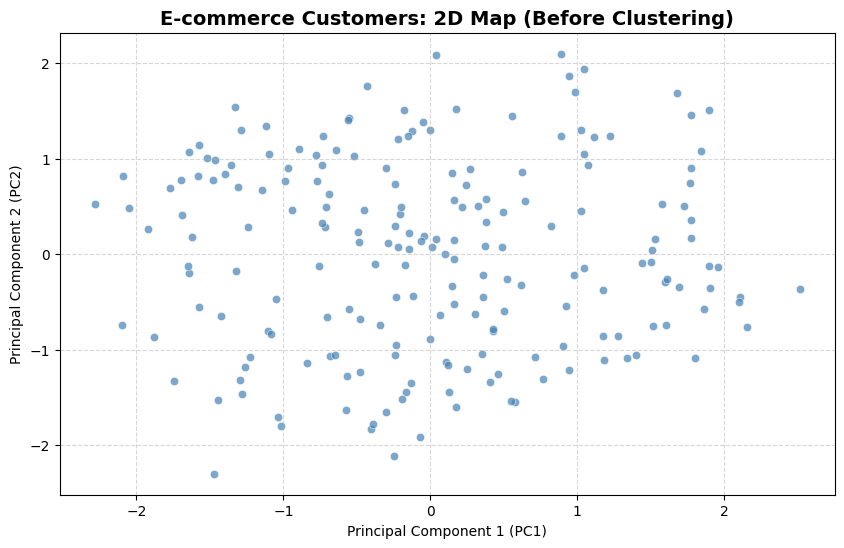

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set up the canvas size
plt.figure(figsize=(10, 6))

# 2. Plot the PCA coordinates (PC1 on X-axis, PC2 on Y-axis)
sns.scatterplot(x='PC1', y='PC2', data=pca_df, alpha=0.7, color='steelblue')

# 3. Add titles and labels for professional presentation
plt.title('E-commerce Customers: 2D Map (Before Clustering)', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.grid(True, linestyle='--', alpha=0.5)

# 4. Display the chart
plt.show()

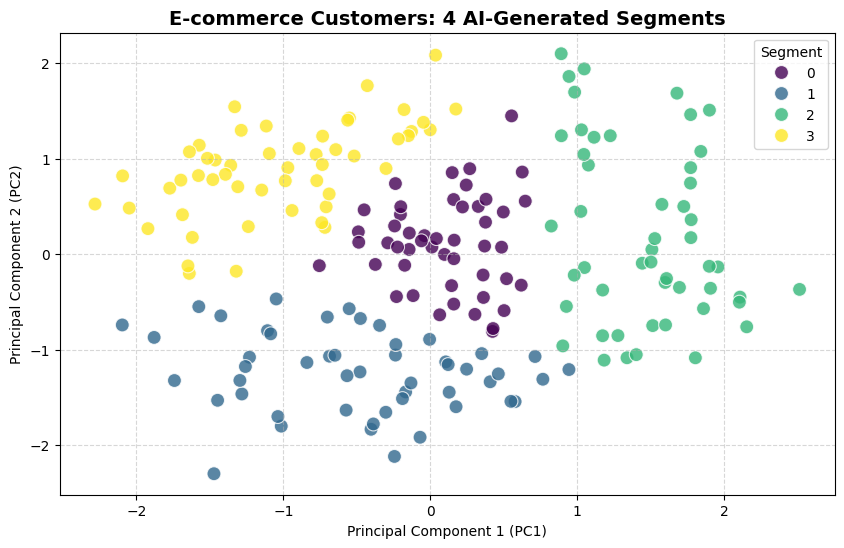

In [8]:
from sklearn.cluster import KMeans

# 1. Initialize K-Means to find 4 distinct customer segments
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')

# 2. Fit the model to our PCA data and assign every customer to a cluster (0, 1, 2, or 3)
clusters = kmeans.fit_predict(pca_df)

# 3. Add these new cluster labels to our dataframe so we can color-code them
pca_df['Customer_Segment'] = clusters

# 4. Plot the newly clustered data
plt.figure(figsize=(10, 6))

# We use the 'hue' parameter to color the dots based on their new Segment
sns.scatterplot(x='PC1', y='PC2', hue='Customer_Segment', data=pca_df, palette='viridis', s=100, alpha=0.8)

plt.title('E-commerce Customers: 4 AI-Generated Segments', fontsize=14, fontweight='bold')
plt.xlabel('Principal Component 1 (PC1)')
plt.ylabel('Principal Component 2 (PC2)')
plt.legend(title='Segment')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [9]:
# 1. Attach the AI-generated cluster labels back to our original unscaled data
retail_df['Customer_Segment'] = clusters

# 2. Calculate the average metrics for each segment
segment_profiles = retail_df.groupby('Customer_Segment')[['Age', 'Annual_Income_k$', 'Spending_Score_1_100']].mean().round(1)

# 3. Display the real-world business profiles
print("--- REAL-WORLD CUSTOMER SEGMENT PROFILES ---")
print(segment_profiles)

--- REAL-WORLD CUSTOMER SEGMENT PROFILES ---
                   Age  Annual_Income_k$  Spending_Score_1_100
Customer_Segment                                              
0                 39.9              84.4                  51.1
1                 55.6              67.2                  23.0
2                 28.0             125.6                  39.2
3                 49.9              69.8                  84.8
